<a href="https://colab.research.google.com/github/UrmishaPal/FAERS-Pipeline/blob/main/second_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Second Project**

# **Load Data**

In [10]:
import pandas as pd
import kagglehub
from kagglehub import kagglehub

# Download latest version
path = kagglehub.dataset_download("kylefengkfeng209/fda-ai-medical-devices-authorizations-and-recalls")

print("Path to dataset files:", path)

100%|██████████| 1.20M/1.20M [00:00<00:00, 82.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kylefengkfeng209/fda-ai-medical-devices-authorizations-and-recalls/versions/1


In [13]:
import os

# The 'path' variable from the previous cell holds the downloaded dataset directory.
# Let's inspect its contents to find the CSV file.
print(f"Contents of downloaded directory: {os.listdir(path)}")

# Assuming there's a CSV file directly in the downloaded path.
# You might need to adjust 'your_file_name.csv' based on the actual contents.
# For example, if 'your_file_name.csv' is 'my_data.csv'.

# Placeholder for the actual CSV file name. You'll need to replace this.
# If there's only one CSV, you can try to automatically find it.
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

df = None
if csv_files:
    # Take the first CSV file found, or specify a particular one if known.
    file_to_read = csv_files[0] # Or 'your_specific_file.csv' if you know it.
    full_file_path = os.path.join(path, file_to_read)
    print(f"Attempting to read: {full_file_path}")
    df = pd.read_csv(full_file_path)
    display(df.head())
else:
    print("No CSV files found directly in the downloaded directory. Please check subdirectories if any.")

# If the CSV is in a subdirectory (e.g., 'data' folder inside 'path'):
# subdirectory_path = os.path.join(path, 'data')
# if os.path.isdir(subdirectory_path):
#     csv_files_in_subdir = [f for f in os.listdir(subdirectory_path) if f.endswith('.csv')]
#     if csv_files_in_subdir:
#         full_file_path = os.path.join(subdirectory_path, csv_files_in_subdir[0])
#         print(f"Attempting to read from subdirectory: {full_file_path}")
#         df = pd.read_csv(full_file_path)
#         display(df.head())
#     else:
#         print("No CSV files found in the 'data' subdirectory.")

Contents of downloaded directory: ['fda_ai_device_recalls.csv', 'fda_ai_product_codes.csv', 'fda_ai_medical_devices.csv']
Attempting to read: /root/.cache/kagglehub/datasets/kylefengkfeng209/fda-ai-medical-devices-authorizations-and-recalls/versions/1/fda_ai_device_recalls.csv


,recall_link_id,submission_number,authorization_pathway,device_name,company_name,final_decision_date,primary_product_code,cfres_id,res_event_number,product_res_number,...,product_description,code_info,product_quantity,reason_for_recall,root_cause_description,action,distribution_pattern,linked_submission_field,linkage_method,source_snapshot_date
0,K240465|220683,K240465,510(k),O-arm O2 Imaging System,"Medtronic Navigation, Inc",2024-06-21,OWB,220683,99041,Z-2451-2026,...,Medtronic O-arm O2 Imaging System. Model Numbe...,Model Number: BI70002000. GTIN (Serial Numbers...,589 units,Potential for image artifacts caused by an ano...,Under Investigation by firm,Medtronic notified consignees on about 05/19/2...,Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
1,K252842|220295,K252842,510(k),SafeOp 3: Neural Informatix System,"Alphatec Spine, Inc.",2026-01-11,GWF,220295,98967,Z-2793-2026,...,"SafeOp Patient Interface, REF: AIX11240, part ...",UDI-DI: 00190376517506.\nSystem Set ID/Patient...,3,"Intraoperative neuromonitoring device, due to ...",Software Design Change,"On 5/13/2026, recall notices were emailed to c...",US Nationwide distribution in the states of TX...,k_numbers,exact_submission_number,2026-07-31
2,K250330|220230,K250330,510(k),3mensio Workstation,Pie Medical Imaging BV,2025-11-03,QIH,220230,98930,Z-2767-2026,...,3mensio Workstation (Vascular Fenestrated) sof...,Software Version 10.7.\nUDIs:\n(01)08056304455...,165,User measurement value reported by diagnostic ...,Software change control,"On 5/7/2026, correction notices were emailed t...",Worldwide - US Nationwide distribution in the ...,k_numbers,exact_submission_number,2026-07-31
3,K213583|219770,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219770,98779,Z-1954-2026,...,Philips Evolution Upgrade 1.5T with MR Elastog...,1. Model Number (REF): 782116. UDI: (01)008848...,8 units,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
4,K213583|219859,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219859,98779,Z-1961-2026,...,Philips Ingenia Ambition X with MR Elastograph...,1. Model Number (REF): 781356. UDI: (01)008848...,86 units,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31


# **Data Preparation**

### **Data Separation as x and y**

In [15]:
y = df['product_quantity']
y

,product_quantity
0,589 units
1,3
2,165
3,8 units
4,86 units
...,...
308,"2,874 units total (1696 units in US)"
309,"1,025 units"
310,85 units of calibrator lot 86280 and 16 units ...
311,"8,804 kits"


In [16]:
x = df.drop ('product_quantity', axis=1 )
x

,recall_link_id,submission_number,authorization_pathway,device_name,company_name,final_decision_date,primary_product_code,cfres_id,res_event_number,product_res_number,...,recall_product_code,product_description,code_info,reason_for_recall,root_cause_description,action,distribution_pattern,linked_submission_field,linkage_method,source_snapshot_date
0,K240465|220683,K240465,510(k),O-arm O2 Imaging System,"Medtronic Navigation, Inc",2024-06-21,OWB,220683,99041,Z-2451-2026,...,OWB,Medtronic O-arm O2 Imaging System. Model Numbe...,Model Number: BI70002000. GTIN (Serial Numbers...,Potential for image artifacts caused by an ano...,Under Investigation by firm,Medtronic notified consignees on about 05/19/2...,Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
1,K252842|220295,K252842,510(k),SafeOp 3: Neural Informatix System,"Alphatec Spine, Inc.",2026-01-11,GWF,220295,98967,Z-2793-2026,...,GWF,"SafeOp Patient Interface, REF: AIX11240, part ...",UDI-DI: 00190376517506.\nSystem Set ID/Patient...,"Intraoperative neuromonitoring device, due to ...",Software Design Change,"On 5/13/2026, recall notices were emailed to c...",US Nationwide distribution in the states of TX...,k_numbers,exact_submission_number,2026-07-31
2,K250330|220230,K250330,510(k),3mensio Workstation,Pie Medical Imaging BV,2025-11-03,QIH,220230,98930,Z-2767-2026,...,QIH,3mensio Workstation (Vascular Fenestrated) sof...,Software Version 10.7.\nUDIs:\n(01)08056304455...,User measurement value reported by diagnostic ...,Software change control,"On 5/7/2026, correction notices were emailed t...",Worldwide - US Nationwide distribution in the ...,k_numbers,exact_submission_number,2026-07-31
3,K213583|219770,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219770,98779,Z-1954-2026,...,LNH,Philips Evolution Upgrade 1.5T with MR Elastog...,1. Model Number (REF): 782116. UDI: (01)008848...,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
4,K213583|219859,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219859,98779,Z-1961-2026,...,LNH,Philips Ingenia Ambition X with MR Elastograph...,1. Model Number (REF): 781356. UDI: (01)008848...,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,K120771|124629,K120771,510(k),UNICEL DXH 800 COULTER CELLULAR ANALYSIS SYSTEM,"BECKMAN COULTER, INC.",2013-03-22,GKZ,124629,67058,Z-1828-2014,...,GKZ,UniCel DxH 800 Coulter Cellular Analysis Syste...,All serial numbers,Beckman Coulter is recalling the UniCel DxH800...,Under Investigation by firm,"An Urgent Product Correction letter, dated 11/...","Worldwide Distribution -- US, Canada, Australi...",k_numbers,exact_submission_number,2026-07-31
309,K120771|122229,K120771,510(k),UNICEL DXH 800 COULTER CELLULAR ANALYSIS SYSTEM,"BECKMAN COULTER, INC.",2013-03-22,GKZ,122229,66382,Z-0147-2014,...,GKZ,UniCel DxH 800 and DxH 600 Coulter Cellular An...,Part Numbers: 629029 for DxH 800 and B23858 fo...,Beckman Coulter is initiating a recall for Uni...,Under Investigation by firm,"The firm, Beckman Coulter, sent an ""URGENT PRO...",Worldwide distribution: US (nationwide) includ...,k_numbers,exact_submission_number,2026-07-31
310,K043341|66439,K043341,510(k),BIOPLEX 2200 ANA SCREEN WITH MEDICAL DECISION ...,"BIO-RAD LABORATORIES, INC.",2005-10-27,NVI,66439,45892,Z-0575-2008,...,NVI,"BioRad BioPlex 2200 Software, for BioPlex 2200...","All software version 2.0, used with Calibrator...",Incorrect values: An

### **Data splitting**

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=100)


In [18]:
x_train

,recall_link_id,submission_number,authorization_pathway,device_name,company_name,final_decision_date,primary_product_code,cfres_id,res_event_number,product_res_number,...,recall_product_code,product_description,code_info,reason_for_recall,root_cause_description,action,distribution_pattern,linked_submission_field,linkage_method,source_snapshot_date
23,K251397|219860,K251397,510(k),"Ingenia, Ingenia CX, Ingenia Elition, Ingenia ...",Philips Medical Systems Nederland B.V.,2025-06-04,LNH,219860,98779,Z-1962-2026,...,LNH,Philips Ingenia Elition S with MR Elastography...,1. Model Number (REF): 781357. UDI: (01)008848...,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
219,K190898|192103,K190898,510(k),Sight OLO,Sight Diagnostics Ltd.,2019-11-01,GKZ,192103,89645,Z-0963-2022,...,GKZ,The Sight OLO device is a computer vision base...,Software versions up to and including v2.59.3....,In instances where custom reference ranges wer...,Software design,Sight Diagnostics issued Medical Device Recall...,Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
10,K213583|219858,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219858,98779,Z-1960-2026,...,LNH,Philips Ingenia Ambition S with MR Elastograph...,1. Model Number (REF): 781359. UDI: (01)008848...,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
235,K203169|188195,K203169,510(k),Revolution Ascend,GE Healthcare Japan Corporation,2020-11-20,JAK,188195,88208,Z-2023-2021,...,JAK,The system is intended to produce cross-sectio...,Revolution CT,When adding one or more intended scan groups n...,Process design,NaN,US,k_numbers,exact_submission_number,2026-07-31
54,K243335|216466,K243335,510(k),"Vantage Galan 3T, MRT-3020, V10.0 with AiCE Re...",Canon Medical Systems Corporation,2025-01-07,LNH,216466,97735,Z-0327-2026,...,LNH,VANTAGE GALAN 3T. CMSC Model: MRT-3020/U7. Mod...,CMSC Model: MRT-3020/U7. Model Number: MEXL-30...,Affected system contains components that do no...,Device Design,Cannon Medical began notifying consignees via ...,US distribution to Ohio and Nevada,k_numbers,exact_submission_number,2026-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,K232491|216365,K232491,510(k),CT 5300,"Philips Healthcare (Suzhou) Co., Ltd.",2024-05-03,JAK,216365,97699,Z-0376-2026,...,JAK,Model: CT 5300;\nProduct Code (REF): 728285;\n...,Product Code (REF): 728285;\nUDI-DI: 008848381...,Issue 1: The potential for unintentional conti...,Under Investigation by firm,"On September 25, 2025, ELECTRONIC PRODUCT RADI...","Domestic: AL, AR, CA, CT, FL, GA, IL, IN, KY, ...",k_numbers,exact_submission_number,2026-07-31
53,K232491|217158,K232491,510(k),CT 5300,"Philips Healthcare (Suzhou) Co., Ltd.",2024-05-03,JAK,217158,97919,Z-0882-2026,...,JAK,"CT 5300;\nSoftware Version Number: 4.5, 5.0, 5.1;",1) Model Number: 728285;\nUDI-DI: 008848381132...,If the screws of tube heat exchanger on the ro...,Under Investigation by firm,"On October 23, 2025 URGENT Medical Device Corr...",Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
79,K231560|215858,K231560,510(k),MAGNETOM Vida; MAGNETOM Lumina; MAGNETOM Aera;...,"Siemens Medical Solutions USA, Inc.",2023-10-23,LNH,215858,97530,Z-2659-2025,...,LNH,MAGNETOM Prisma. Model Number: 10849582.,Model Number: 10849582. UDI Numbers: (01)04056...,There is a potential for an ice blockage to fo...,Under Investigation by firm,Siemens Healthcare notified consignees on abou...,Worldwide distribution - US Nationwide and the...,k_numbers,exact_submis

In [19]:
x_test

,recall_link_id,submission_number,authorization_pathway,device_name,company_name,final_decision_date,primary_product_code,cfres_id,res_event_number,product_res_number,...,recall_product_code,product_description,code_info,reason_for_recall,root_cause_description,action,distribution_pattern,linked_submission_field,linkage_method,source_snapshot_date
310,K043341|66439,K043341,510(k),BIOPLEX 2200 ANA SCREEN WITH MEDICAL DECISION ...,"BIO-RAD LABORATORIES, INC.",2005-10-27,NVI,66439,45892,Z-0575-2008,...,NVI,"BioRad BioPlex 2200 Software, for BioPlex 2200...","All software version 2.0, used with Calibrator...",Incorrect values: An error was found in the B...,Software design,Bio-Rad sent a Voluntary Field Correction noti...,"Worldwide Distribution - USA, Canada, France, ...",k_numbers,exact_submission_number,2026-07-31
169,K220141|206468,K220141,510(k),RayStation 11B,RaySearch Laboratories AB (publ),2022-04-15,MUJ,206468,94153,Z-1482-2024,...,MUJ,RayStation Software Version Numbers version nu...,Version Number (Build Number/UDI): 8B (8.1.0.4...,A use error that has occurred with RayStation/...,Under Investigation by firm,"On February 26, 2024, the firm notified custom...",Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
1,K252842|220295,K252842,510(k),SafeOp 3: Neural Informatix System,"Alphatec Spine, Inc.",2026-01-11,GWF,220295,98967,Z-2793-2026,...,GWF,"SafeOp Patient Interface, REF: AIX11240, part ...",UDI-DI: 00190376517506.\nSystem Set ID/Patient...,"Intraoperative neuromonitoring device, due to ...",Software Design Change,"On 5/13/2026, recall notices were emailed to c...",US Nationwide distribution in the states of TX...,k_numbers,exact_submission_number,2026-07-31
27,K251397|219867,K251397,510(k),"Ingenia, Ingenia CX, Ingenia Elition, Ingenia ...",Philips Medical Systems Nederland B.V.,2025-06-04,LNH,219867,98779,Z-1969-2026,...,LNH,Philips Upgrade to MR 7700 with MR Elastograph...,1. Model Number (REF): 782130. UDI: (01)008848...,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
126,K220141|212155,K220141,510(k),RayStation 11B,RaySearch Laboratories AB (publ),2022-04-15,MUJ,212155,96156,Z-1190-2025,...,MUJ,Brand Name: RayStation- Intended as a Radiatio...,"Lot Code: UDI: 0735000201042620211208, 073500...",Inconsistency in the use of Density uncertaint...,Under Investigation by firm,"Raysearch issued Field Safety Notice, Medical ...",Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,K212441|199964,K212441,510(k),Philips Incisive CT,"Philips Healthcare (Suzhou) Co., Ltd.",2022-04-27,JAK,199964,92238,Z-1624-2023,...,JAK,Incisive CT Power- Whole-body computed tomogra...,UDI-DI: (01)00884838103467 (21)\nSerial Number...,Potential for Incorrect Image Orientation resu...,Software design,Philips issued Urgent Medical Device Correctio...,"AR, CA, OK, TX\nForeign:\nCountry\nArgentina\n...",k_numbers,exact_submission_number,2026-07-31
88,K210645|215504,K210645,510(k),RayStation 10.1,RaySearch Laboratories AB (publ),2021-06-29,MUJ,215504,97400,Z-2490-2025,...,MUJ,RayStation with the following product descript...,"1.\tSoftware Version: 10.1.0.613, UDI: 0735000...",DICOM SOP Instance UID and Series Instance UID...,Under Investigation by firm,RaySearch notified consignees on about 08/08/2...,Worldwide - US Nationwide distribution in the ...,k_numbers,exact_submission_number,2026-07-31
157,K222312|207142,K222312,510(k),RayStation 12A,RaySearch Laboratories AB (publ),2023-03-29,MUJ,207142,94388,Z-1750-2024,...,MUJ,"RayStation 13.0.0.1547, 13.1.0.144 & 13.1.1.89...","UDI: 0735000201054920220616, 07350002010679202...",Potential for reported SSD to be too high.,Software design,A Field Safety N

# **Model Building**

### **Linear Regression**

### Training the model

In [21]:
from sklearn.linear_model import LinearRegression
import re
import numpy as np # Import numpy for NaN handling
import pandas as pd # Import pandas for to_numeric and isna

# 1. Preprocess y_train and y_test to extract numerical quantity
def extract_number_from_quantity(text):
    if pd.isna(text):
        return np.nan
    if isinstance(text, (int, float)):
        return text
    if isinstance(text, str):
        text = text.replace(',', '') # Remove commas for proper number parsing
        match = re.search(r'(\d+\.?\d*)', text) # Find first sequence of digits and optional decimal
        if match:
            return float(match.group(1))
    return np.nan # Return NaN for unparseable strings

y_train_cleaned = y_train.apply(extract_number_from_quantity)
y_test_cleaned = y_test.apply(extract_number_from_quantity)

# Impute NaNs in y_train_cleaned and y_test_cleaned (using median from training data)
median_y_train = y_train_cleaned.median()
y_train_cleaned = y_train_cleaned.fillna(median_y_train)
y_test_cleaned = y_test_cleaned.fillna(median_y_train)

# 2. Preprocess x_train and x_test to select only numerical features
# Based on the df head, 'cfres_id' and 'res_event_number' appear to be the only inherently numerical columns.
# Other columns are strings (IDs, names, descriptions, dates) and need more complex preprocessing (like one-hot encoding or feature engineering for dates)
# which is beyond a simple direct numerical conversion to resolve this error.
# For now, we will select these two numerical columns.

numerical_features = ['cfres_id', 'res_event_number']

x_train_processed = x_train[numerical_features].copy()
x_test_processed = x_test[numerical_features].copy()

# Ensure selected columns are truly numeric (coerce non-numeric to NaN)
for col in numerical_features:
    x_train_processed[col] = pd.to_numeric(x_train_processed[col], errors='coerce')
    x_test_processed[col] = pd.to_numeric(x_test_processed[col], errors='coerce')

# Impute missing values in x_train_processed and x_test_processed (using median from training data)
for col in numerical_features:
    if x_train_processed[col].isnull().any():
        median_val = x_train_processed[col].median()
        x_train_processed[col] = x_train_processed[col].fillna(median_val)
        x_test_processed[col] = x_test_processed[col].fillna(median_val)

# Initialize and fit the Linear Regression model with the processed data
lr = LinearRegression()
lr.fit(x_train_processed, y_train_cleaned)

LinearRegression()

### Applying the model to make prediction

In [22]:
y_lr_train_pred = lr.predict(x_train_processed)
y_lr_test_pred = lr.predict(x_test_processed)

In [23]:
print(y_lr_train_pred)

[  3153.73666823  23083.89465958   3174.60569006  21431.51588417
   7742.17087583   6746.8817087    7743.51527063  14159.51620667
   7148.88467266   3101.56411366  18001.25316594   6594.24589975
   8314.26035276   7658.68773156   5599.93089768  15968.07719281
  14128.21267393  11867.81400875   6656.85296523  16559.22835964
   6681.45062093  15822.83168096   9909.90993859  16548.79384873
   6300.32701021   5886.781429     7823.42240209  40844.16116346
  16790.01802451  16517.49031599  16527.9248269    8286.19032288
   4852.01803011  23015.66985217  13897.48610541   5964.91083959
   3091.12960275  16672.35903437  22810.46939644  21650.33735426
   5115.93723943   9059.99307583   6658.94040234  28663.17606096
   4092.84265049   6258.09383555   6104.71051018  14190.82232226
  22779.90115745   6646.19438852   6656.62889943   6189.38224551
   5667.65669981  23873.3163393   16580.09738147  17632.41770586
   6396.89420414   6133.35486436   7743.51527063   6158.21265403
   5740.69827621  19182.1

In [24]:
y_lr_test_pred

array([42426.92392081,  6300.32701021,  4165.8198391 ,  3080.69509184,
        6102.05133162,  4071.97362866,  8423.26255286, 13755.37234906,
        9065.77049579,  6658.32613559,  4071.97362866,  8293.39133093,
       14138.64718484,  8043.73184806, 39502.7045416 ,  7148.88467266,
        5763.70302598,  9750.49551644, 59913.62587102, 22370.05718193,
        9076.2050067 ,  5958.62735738, 13164.17358299,  8012.42831532,
       16141.23882204, 24175.87144783, 17884.60888315,  6667.06341034,
       45699.48218375,  6237.63946   , 22604.25870748, 16563.92082717,
       23845.08792283, 11867.81400875,  6147.77814311,  6210.08900646,
        3276.65350198, 14117.77816301,  7176.79631594,  6122.92035345,
       21044.22336111,  7854.67187847,  6300.32701021, 22858.33640998,
       15922.83905518, 22810.46939644, 16611.40091421,  6112.48584253,
       21832.04438635,  6116.47461037,  3153.73666823,  7475.11474532,
        6168.64716494, 16595.22435991, 28011.68938909, 16444.44873959,
      

**Evaluate model performance**

In [25]:
y_train

,product_quantity
23,6 units
219,322 units: U.S 109 Foreign 213
10,7 units
235,NaN
54,2 units
...,...
66,165 units
53,6 units (OUS only)
79,101 units
280,1 system in the U.S.


In [26]:
y_lr_test_pred

array([42426.92392081,  6300.32701021,  4165.8198391 ,  3080.69509184,
        6102.05133162,  4071.97362866,  8423.26255286, 13755.37234906,
        9065.77049579,  6658.32613559,  4071.97362866,  8293.39133093,
       14138.64718484,  8043.73184806, 39502.7045416 ,  7148.88467266,
        5763.70302598,  9750.49551644, 59913.62587102, 22370.05718193,
        9076.2050067 ,  5958.62735738, 13164.17358299,  8012.42831532,
       16141.23882204, 24175.87144783, 17884.60888315,  6667.06341034,
       45699.48218375,  6237.63946   , 22604.25870748, 16563.92082717,
       23845.08792283, 11867.81400875,  6147.77814311,  6210.08900646,
        3276.65350198, 14117.77816301,  7176.79631594,  6122.92035345,
       21044.22336111,  7854.67187847,  6300.32701021, 22858.33640998,
       15922.83905518, 22810.46939644, 16611.40091421,  6112.48584253,
       21832.04438635,  6116.47461037,  3153.73666823,  7475.11474532,
        6168.64716494, 16595.22435991, 28011.68938909, 16444.44873959,
      

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_train_mse = mean_squared_error(y_train_cleaned, y_lr_train_pred)
lr_train_r2 = r2_score(y_train_cleaned, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test_cleaned, y_lr_test_pred)
lr_test_r2 = r2_score(y_test_cleaned, y_lr_test_pred)

In [28]:
lr_train_mse

5145553251.720252

In [29]:
lr_train_r2

0.028709558791861434

In [30]:
lr_test_mse

337855487.6294439

In [31]:
lr_test_r2

-3.6591383045004617

In [33]:
print ('LR MSE (Train):', lr_train_mse)
print ('LR R2 (Train):', lr_train_r2)
print ('LR MSE (Test):', lr_test_mse)
print ('LR R2 (Test):', lr_test_r2)

LR MSE (Train): 5145553251.720252
LR R2 (Train): 0.028709558791861434
LR MSE (Test): 337855487.6294439
LR R2 (Test): -3.6591383045004617


In [35]:
lr_reults = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MSE (Train)': [lr_train_mse],
    'R2 (Train)': [lr_train_r2],
    'MSE (Test)': [lr_test_mse],
    'R2 (Test)': [lr_test_r2]})


In [36]:
lr_reults

,Model,MSE (Train),R2 (Train),MSE (Test),R2 (Test)
0,Linear Regression,5.145553e+09,0.02871,3.378555e+08,-3.659138


In [37]:
lr_reults.colums = ['Model', 'MSE (Train)', 'R2 (Train)', 'MSE (Test)', 'R2 (Test)']

/tmp/ipykernel_5561/2130669011.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  lr_reults.colums = ['Model', 'MSE (Train)', 'R2 (Train)', 'MSE (Test)', 'R2 (Test)']


In [38]:
lr_reults

,Model,MSE (Train),R2 (Train),MSE (Test),R2 (Test)
0,Linear Regression,5.145553e+09,0.02871,3.378555e+08,-3.659138


## **Random Forest**

### **Training the mode;**

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train_processed, y_train_cleaned)

RandomForestRegressor(max_depth=2, random_state=100)

### **Applying the model to make a prediction**

In [42]:
y_rf_train_pred = rf.predict(x_train_processed)
y_rf_test_pred = rf.predict(x_test_processed)

### **Evaluate model performace**

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_train_mse = mean_squared_error(y_train_cleaned, y_rf_train_pred)
rf_train_r2 = r2_score(y_train_cleaned, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test_cleaned, y_rf_test_pred)
rf_test_r2 = r2_score(y_test_cleaned, y_rf_test_pred)

In [47]:
rf_results = pd.DataFrame(['Random forest',rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Model', 'MSE (Train)', 'R2 (Train)', 'MSE (Test)', 'R2 (Test)']

In [48]:
rf_results


,Model,MSE (Train),R2 (Train),MSE (Test),R2 (Test)
0,Random forest,2504586263.045414,0.527227,578285931.50493,-6.974753


## **Model Comparison**

In [50]:
df_models = pd.concat([lr_reults, rf_results], axis=0)

In [51]:
df_models.reset_index(drop=True)

,Model,MSE (Train),R2 (Train),MSE (Test),R2 (Test)
0,Linear Regression,5145553251.720252,0.02871,337855487.629444,-3.659138
1,Random forest,2504586263.045414,0.527227,578285931.50493,-6.974753


# **Data visualizatin of prediction results**

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

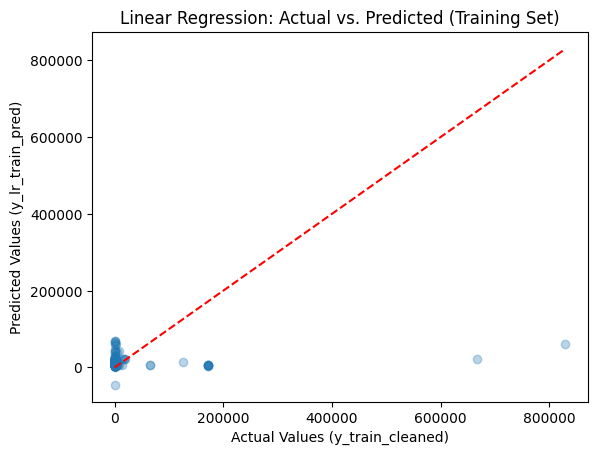

In [54]:
plt.scatter(x=y_train_cleaned, y=y_lr_train_pred, alpha=0.3)
plt.xlabel('Actual Values (y_train_cleaned)')
plt.ylabel('Predicted Values (y_lr_train_pred)')
plt.title('Linear Regression: Actual vs. Predicted (Training Set)')
plt.plot([min(y_train_cleaned), max(y_train_cleaned)], [min(y_train_cleaned), max(y_train_cleaned)], color='red', linestyle='--') # Add a perfect prediction line
plt.show()